In [1]:
import numpy as np
import pandas as pd
import tifffile as tiff
import healpy as hp
from scipy import interpolate

In [2]:
import rasterio
import numpy as np

# Open the GeoTIFF file
file_path = '/home/pratush/Desktop/USA_shpraster.tif'
src = rasterio.open(file_path)

# Read the raster data as a numpy array
data = src.read(1)  # Assuming a single-band raster

# Find pixels with non-zero values
non_zero_pixels = np.where(data != 0)

# Get the coordinates (latitude, longitude) of non-zero pixels
lat=[]
lon=[]
for y, x in zip(*non_zero_pixels):
    lonval, latval = src.xy(y, x)  # Get the longitude and latitude of the pixel
    lat.append(latval)
    lon.append(lonval)


In [3]:
np.shape(lat)

(466292,)

In [4]:
pix=hp.ang2pix(128,lon,lat,lonlat=True)

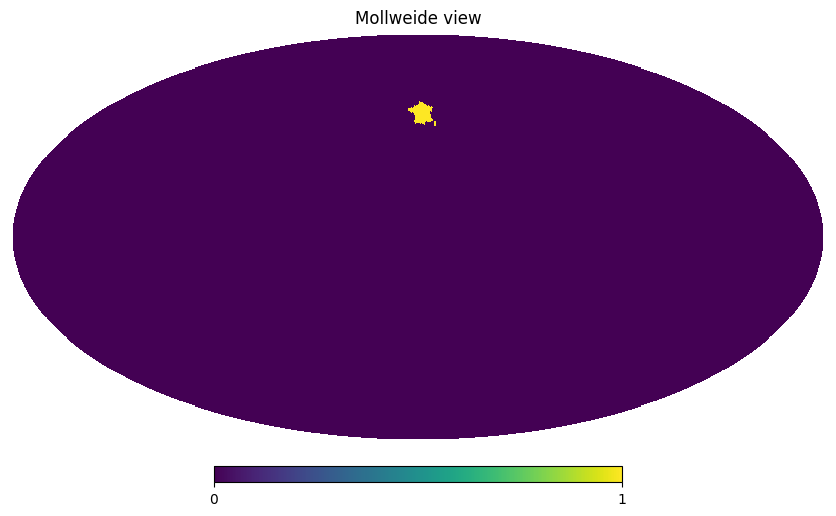

In [6]:
new=np.zeros(hp.nside2npix(128))
for pi in pix:
    new[pi]+=1
new=np.where(new != 0, 1, 0)
hp.mollview(new,flip='geo')